# Examples for `corr_torch` functions

Examples on how to use `statresp.corr_torch` on synthetic dF/F data. `corr_torch` is batched function with PyTorch, so it should be fast.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from statresp import corr_torch as corr
from statresp import _slice

WINDOW = (0.0, 2.0)

## Synthetic data

`generate_traces` helper function generates synthetic dFF data and ground-truth spikes.


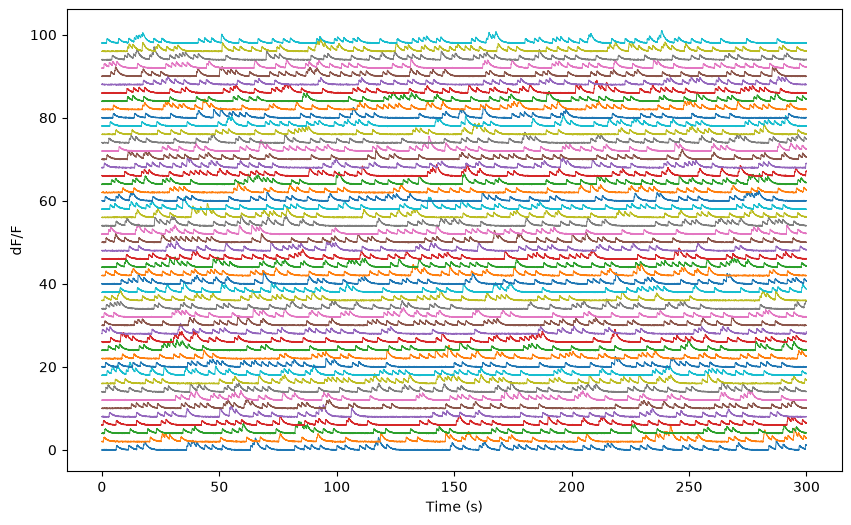

In [2]:
import numpy as np
from scipy.signal import fftconvolve

# GCaMP6s kinetics
TAU_RISE = 0.1    # s
TAU_DECAY = 1.5   # s
RATE = 0.2        # mean firing rate (Hz)

def generate_traces(
    n_cells=10,
    duration=300.0,        # s
    fs=45.0,              # imaging frame rate (Hz)
    seed=2026,
):
    """
    Simulate dF/F traces from Poisson spike trains.
    """
    rng = np.random.default_rng(seed)
    n_frames = int(round(duration * fs))
    dt = 1 / fs

    spikes_hi = rng.poisson(RATE * dt, (n_cells, n_frames))

    # double-exponential kernel, peak = AMP
    kt = np.arange(0, 8 * TAU_DECAY, dt)
    kernel = np.exp(-kt / TAU_DECAY) - np.exp(-kt / TAU_RISE)
    kernel *= 1 / kernel.max()

    ca = fftconvolve(spikes_hi, kernel[None], axes=1)[:, : spikes_hi.shape[1]]

    # downsample: mean within frame (integration), sum spikes
    clean = ca.reshape(n_cells, n_frames, 1).mean(-1)
    spikes = spikes_hi.reshape(n_cells, n_frames, 1).sum(-1)
    dff = clean + rng.normal(0, 0.05, clean.shape) # add noise

    return np.arange(n_frames) / fs, dff, spikes

t, dff, spks = generate_traces(n_cells=50)
offset = 2
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(dff.shape[0]):
    y0 = i * offset
    ax.plot(t, dff[i] + y0, lw=0.7)
    # ax.vlines(t[spks[i] > 0], y0 - 0.3, y0 - 0.1, color="k", lw=0.5)  # spike ticks

ax.set_xlabel("Time (s)")
ax.set_ylabel("dF/F")
plt.show()

## Batched calculation of correlation matrix


In [3]:
def time_call(callable_fn, repeats=7):
    """Runs callable_fn() `repeats` times, returns (mean_s, std_s, last_result)."""
    times = np.empty(repeats)
    result = None
    for i in range(repeats):
        t0 = time.perf_counter()
        result = callable_fn()
        times[i] = time.perf_counter() - t0
    return float(times.mean()), float(times.std()), result

In [6]:
def make_cube(n_cell=5, duration=8.0, n_time=15, seed=0, fs=45.0):
    rng = np.random.default_rng(seed)
    time_ax = np.linspace(-0.5, 2.0, n_time)

    _, dff, _ = generate_traces(n_cells=n_cell, duration=duration, fs=fs, seed=seed)
    n_trial = dff.shape[1] // n_time  # frames actually generated, floored to whole trials

    direction = rng.choice([0, 90, 180, 270], size=n_trial)
    sf = rng.choice([0.02, 0.04], size=n_trial)
    tf = rng.choice([1, 2], size=n_trial)
    data = dff[:, : n_trial * n_time].reshape(n_cell, n_trial, n_time)

    return xr.DataArray(
        data,
        dims=("cell", "trial", "time"),
        coords={
            "cell": np.arange(n_cell),
            "trial": np.arange(n_trial),
            "time": time_ax,
            "direction": ("trial", direction),
            "sf": ("trial", sf),
            "tf": ("trial", tf),
        },
    )

def total_corr_cube(cube, window=None, device=None):
    x = _slice(cube, window).stack(sample=("trial", "time")).transpose("cell", "sample")
    return corr.total_corr_matrix(x, time_dim="sample", device=device)


CORR_FUNCS = [
    ("cosangle", corr.cosangle_matrix),
    ("signal_corr", corr.signal_corr_matrix),
    ("noise_corr", corr.noise_corr_matrix),
    ("total_corr", total_corr_cube),
]
N_CELLS = [10, 100, 500, 1000]
N_DURATIONS = [10, 100, 500, 1000]

corr_records = []
for n_cell in N_CELLS:
    for duration in N_DURATIONS:
        cube = make_cube(n_cell=n_cell, duration=duration, n_time=15, seed=0)
        for name, matrix_fn in CORR_FUNCS:
            mean_mat, std_mat, _ = time_call(
                lambda mf=matrix_fn: mf(cube, window=WINDOW, device="cpu"), repeats=7
            )
            corr_records.append(
                {
                    "function": name,
                    "n_cell": n_cell,
                    "duration": duration,
                    "batched_matrix_s": mean_mat,
                    "batched_matrix_std": std_mat,
                }
            )

corr_df = pd.DataFrame(corr_records)
corr_df


,function,n_cell,duration,batched_matrix_s,batched_matrix_std
0,cosangle,10,10,0.011145,0.001236
1,signal_corr,10,10,0.010823,0.001730
2,noise_corr,10,10,0.001410,0.000285
3,total_corr,10,10,0.004271,0.000385
4,cosangle,10,100,0.011747,0.000533
...,...,...,...,...,...
59,total_corr,1000,500,0.543767,0.102173
60,cosangle,1000,1000,1.269771,0.180018
61,signal_corr,1000,1000,1.023290,0.070468
62,noise_corr,1000,1000,1.808594,0.066597


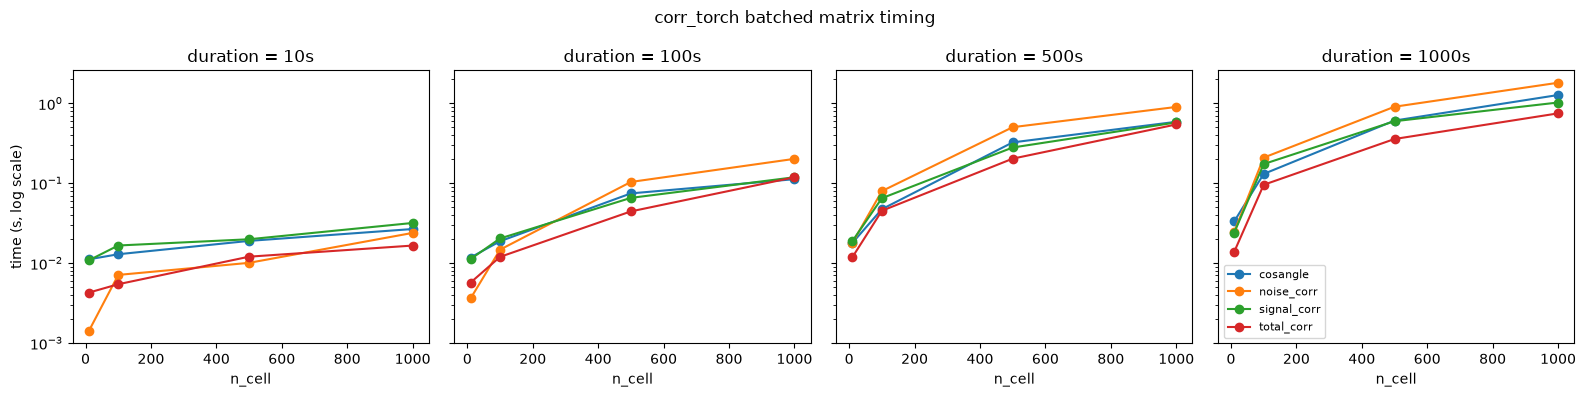

In [7]:
fig, axes = plt.subplots(1, len(N_DURATIONS), figsize=(4 * len(N_DURATIONS), 4), sharey=True)

for ax, duration in zip(axes, N_DURATIONS):
    sub = corr_df[corr_df["duration"] == duration]
    for name, group in sub.groupby("function"):
        ax.plot(group["n_cell"], group["batched_matrix_s"], "o-", label=name)
    ax.set_yscale("log")
    ax.set_xlabel("n_cell")
    ax.set_title(f"duration = {duration:g}s")

axes[0].set_ylabel("time (s, log scale)")
axes[-1].legend(fontsize=8)
fig.suptitle("corr_torch batched matrix timing")
fig.tight_layout()
plt.show()

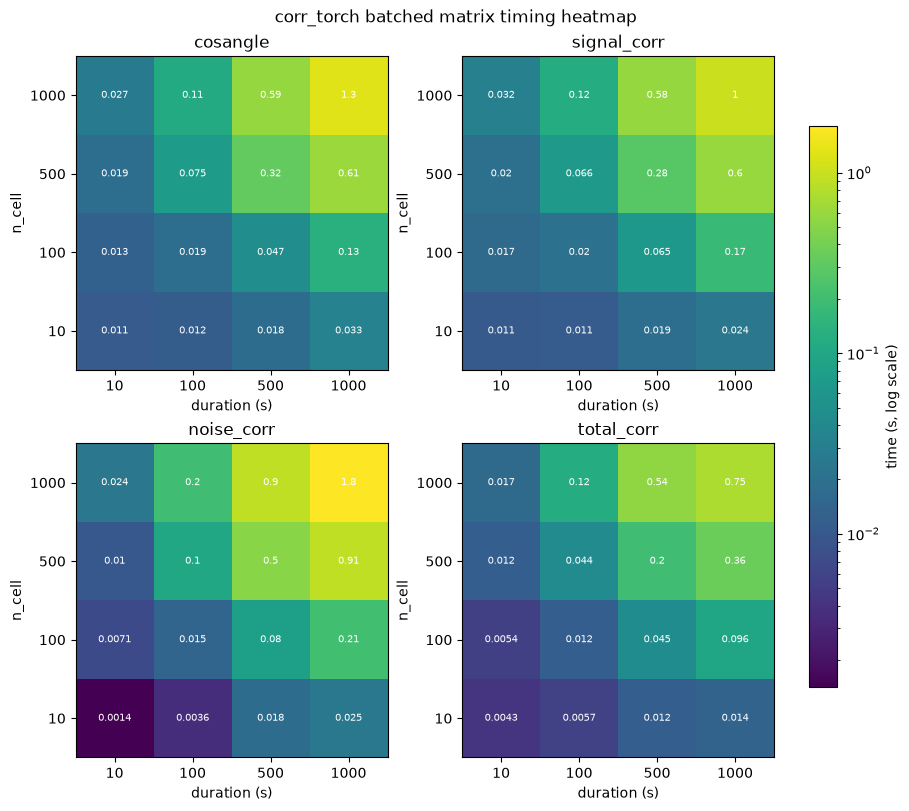

In [8]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
vmin = corr_df["batched_matrix_s"].min()
vmax = corr_df["batched_matrix_s"].max()

for ax, (name, _) in zip(axes.flat, CORR_FUNCS):
    sub = corr_df[corr_df["function"] == name]
    pivot = sub.pivot(index="n_cell", columns="duration", values="batched_matrix_s")
    im = ax.imshow(
        pivot.values,
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        aspect="auto",
        origin="lower",
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("duration (s)")
    ax.set_ylabel("n_cell")
    ax.set_title(name)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2g}", ha="center", va="center",
                     color="white", fontsize=7)

fig.colorbar(im, ax=axes, shrink=0.8, label="time (s, log scale)")
fig.suptitle("corr_torch batched matrix timing heatmap")
plt.show()